<a href="https://colab.research.google.com/github/rkk7452/GIM_TEC_Extraction/blob/main/Extract_GIM_TEC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extract the GIM files

In [ ]:
pip install gnssanalysis

In [ ]:
import numpy as np
import pandas as pd
import os
import re
import xarray
from gnssanalysis import gn_io
from datetime import datetime
import pytz
import scipy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
from google.colab import files
uploaded = files.upload() # upload the files

"""
Using:

uqrg1270.25i                              Final product, 15 min resolution
IGS0OPSFIN_20251270000_01D_02H_GIM.INX   Final product, 2 hour resolution
UPC0OPSRAP_20251270000_01D_02H_GIM.INX    Rapid product, 2 hour resolution
UPC0OPSRAP_20251270000_01D_01H_GIM.INX    Rapid product, 1 hour resolution
UPC0OPSRAP_20251270000_01D_15M_GIM.INX    Rapid product, 15 min resolution

"""

Saving UPC0OPSRAP_20251270000_01D_01H_GIM.INX to UPC0OPSRAP_20251270000_01D_01H_GIM (2).INX
Saving UPC0OPSRAP_20251270000_01D_02H_GIM.INX to UPC0OPSRAP_20251270000_01D_02H_GIM (2).INX
Saving UPC0OPSRAP_20251270000_01D_15M_GIM.INX to UPC0OPSRAP_20251270000_01D_15M_GIM (2).INX
Saving uqrg1270.25i to uqrg1270 (2).25i
Saving IGS0OPSFIN_20251270000_01D_02H_GIM.INX to IGS0OPSFIN_20251270000_01D_02H_GIM (2).INX


'\nUsing:\n\nuqrg1270.25i                              Final product, 15 min resolution\nIGS0OPSFIN_20251270000_01D_02H_GIM.INX   Final product, 2 hour resolution\nUPC0OPSRAP_20251270000_01D_02H_GIM.INX    Rapid product, 2 hour resolution\nUPC0OPSRAP_20251270000_01D_01H_GIM.INX    Rapid product, 1 hour resolution\nUPC0OPSRAP_20251270000_01D_15M_GIM.INX    Rapid product, 15 min resolution\n\n'

In [ ]:
ionex_2hr = gn_io.ionex.read_ionex("/content/IGS0OPSFIN_20251270000_01D_02H_GIM.INX")
ionex_2hr_r = gn_io.ionex.read_ionex("/content/UPC0OPSRAP_20251270000_01D_02H_GIM.INX")
ionex_1hr = gn_io.ionex.read_ionex("/content/UPC0OPSRAP_20251270000_01D_01H_GIM.INX")
ionex_15m = gn_io.ionex.read_ionex("/content/UPC0OPSRAP_20251270000_01D_15M_GIM.INX")

In [ ]:
targetLat = 37.5 # closest to 37.239777271
targetLon = -120 # closest to -118.281666695
minTime = "2025-05-07 08:00:00" # earliest time we want
maxTime = "2025-05-07 12:00:00" # latest time we want
originTime = pd.Timestamp('2000-01-01 12:00:00') # seconds-based time is seconds after the originTime

# to keep the numerical values for interpolating later, the "Time" column is the seconds after noon, Jan 1, 2000.
#The "DateTime" column is the datetime object created from the "Time column"


#2 hour final dataset
epoch_2h = ionex_2hr.index.get_level_values("DateTime").unique()[0] # get time values (in seconds after noon on jan 1 2000)

tec_df_2h = (
    ionex_2hr
    .xs("TEC", level="Type")      # Keep only TEC rows
    .stack()                      # Turn longitude columns into rows
    .reset_index()                # Convert index levels to columns
    .rename(columns={0: "TEC"})   # Name the TEC values
    .rename(columns={'DateTime': "Time"}) # rename to time, the seconds after noon jan 1 2000
)
tec_df_2h["DateTime"] = pd.to_datetime(tec_df_2h["Time"], unit="s", origin = originTime, utc=True) # convert to formatted times

ovro_tec_2h = tec_df_2h[(tec_df_2h['Lat'] == targetLat) &
                        (tec_df_2h['Lon'] == targetLon) &
                        (tec_df_2h["DateTime"] >= minTime) &
                        (tec_df_2h["DateTime"] <= maxTime)] # filter to only rows at the correct position and time

#2 hour rapid dataset
epoch_2h_r = ionex_2hr_r.index.get_level_values("DateTime").unique()[0] # get time values (in seconds after noon on jan 1 2000)

tec_df_2h_r = (
    ionex_2hr_r
    .xs("TEC", level="Type")      # Keep only TEC rows
    .stack()                      # Turn longitude columns into rows
    .reset_index()                # Convert index levels to columns
    .rename(columns={0: "TEC"})   # Name the TEC values
    .rename(columns={'DateTime': "Time"}) # rename to time, the seconds after noon jan 1 2000
)
tec_df_2h_r["DateTime"] = pd.to_datetime(tec_df_2h_r["Time"], unit="s", origin = originTime, utc=True) # convert to formatted times

ovro_tec_2h_r = tec_df_2h_r[(tec_df_2h_r['Lat'] == targetLat) &
                        (tec_df_2h_r['Lon'] == targetLon) &
                        (tec_df_2h_r["DateTime"] >= minTime) &
                        (tec_df_2h_r["DateTime"] <= maxTime)] # filter to only rows at the correct position and time


#1 hour rapid dataset
epoch_1h = ionex_1hr.index.get_level_values("DateTime").unique()[0] # get time values (in seconds after noon on jan 1 2000)

tec_df_1h = (
    ionex_1hr
    .xs("TEC", level="Type")      # Keep only TEC rows
    .stack()                      # Turn longitude columns into rows
    .reset_index()                # Convert index levels to columns
    .rename(columns={0: "TEC"})   # Name the TEC values
    .rename(columns={'DateTime': "Time"}) # rename to time, the seconds after noon jan 1 2000
)
tec_df_1h["DateTime"] = pd.to_datetime(tec_df_1h["Time"], unit="s", origin = originTime, utc=True) # convert to formatted times

ovro_tec_1h = tec_df_1h[(tec_df_1h['Lat'] == targetLat) &
                        (tec_df_1h['Lon'] == targetLon) &
                        (tec_df_1h["DateTime"] >= minTime) &
                        (tec_df_1h["DateTime"] <= maxTime)] # filter to only rows at the correct position and time


#15 min rapid dataset
epoch_15m = ionex_15m.index.get_level_values("DateTime").unique()[0] # get time values (in seconds after noon on jan 1 2000)

tec_df_15m = (
    ionex_15m
    .xs("TEC", level="Type")      # Keep only TEC rows
    .stack()                      # Turn longitude columns into rows
    .reset_index()                # Convert index levels to columns
    .rename(columns={0: "TEC"})   # Name the TEC values
    .rename(columns={'DateTime': "Time"}) # rename to time, the seconds after noon jan 1 2000
)
tec_df_15m["DateTime"] = pd.to_datetime(tec_df_15m["Time"], unit="s", origin = originTime, utc=True) # convert to formatted times

ovro_tec_15m = tec_df_15m[(tec_df_15m['Lat'] == targetLat) &
                        (tec_df_15m['Lon'] == targetLon) &
                        (tec_df_15m["DateTime"] >= minTime) &
                        (tec_df_15m["DateTime"] <= maxTime)] # filter to only rows at the correct position and time

#display all
display(ovro_tec_2h.head())
display(ovro_tec_2h_r.head())
display(ovro_tec_1h.head())
display(ovro_tec_15m.head())

,Time,Lat,Lon,TEC,DateTime
22204,799876800,37.5,-120.0,14.7,2025-05-07 08:00:00+00:00
27387,799884000,37.5,-120.0,13.5,2025-05-07 10:00:00+00:00
32570,799891200,37.5,-120.0,11.9,2025-05-07 12:00:00+00:00


,Time,Lat,Lon,TEC,DateTime
22204,799876800,37.5,-120.0,12.7,2025-05-07 08:00:00+00:00
27387,799884000,37.5,-120.0,12.3,2025-05-07 10:00:00+00:00
32570,799891200,37.5,-120.0,11.6,2025-05-07 12:00:00+00:00


,Time,Lat,Lon,TEC,DateTime
42936,799876800,37.5,-120.0,11.7,2025-05-07 08:00:00+00:00
48119,799880400,37.5,-120.0,11.2,2025-05-07 09:00:00+00:00
53302,799884000,37.5,-120.0,12.4,2025-05-07 10:00:00+00:00
58485,799887600,37.5,-120.0,10.9,2025-05-07 11:00:00+00:00
63668,799891200,37.5,-120.0,11.0,2025-05-07 12:00:00+00:00


,Time,Lat,Lon,TEC,DateTime
167328,799876800,37.5,-120.0,11.7,2025-05-07 08:00:00+00:00
172511,799877700,37.5,-120.0,11.7,2025-05-07 08:15:00+00:00
177694,799878600,37.5,-120.0,11.5,2025-05-07 08:30:00+00:00
182877,799879500,37.5,-120.0,11.7,2025-05-07 08:45:00+00:00
188060,799880400,37.5,-120.0,11.2,2025-05-07 09:00:00+00:00


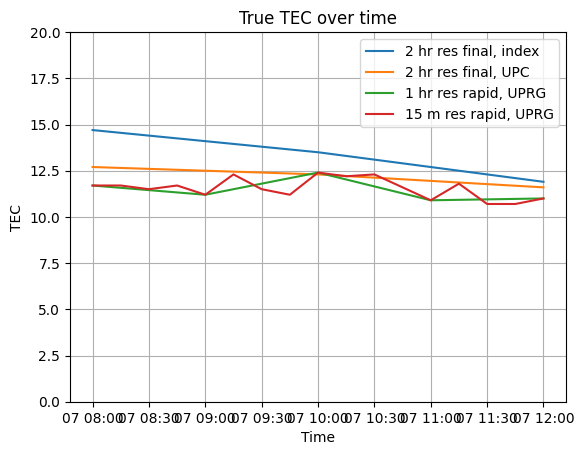

In [ ]:
a = ovro_tec_2h.copy().drop(columns=['Lat','Lon']) # 2 hour final, index
b = ovro_tec_2h_r.copy().drop(columns=['Lat','Lon']) # 2 hour final, UPC
c = ovro_tec_1h.copy().drop(columns=['Lat','Lon']) # 1 hour rapid
d = ovro_tec_15m.copy().drop(columns=['Lat','Lon']) # 15 min rapid, potentially lower quality UPRG

fig, ax = plt.subplots()
ax.plot(a['DateTime'], a['TEC'], label = '2 hr res final, index')
ax.plot(b['DateTime'], b['TEC'], label = '2 hr res final, UPC')
ax.plot(c['DateTime'], c['TEC'], label = '1 hr res rapid, UPRG')
ax.plot(d['DateTime'], d['TEC'], label = '15 m res rapid, UPRG')

ax.set_ylim(0,20)

ax.set(xlabel='Time', ylabel='TEC',
       title='True TEC over time')
ax.grid()

plt.legend(loc="upper right")

plt.show()

# Extract Timestamps from Combined CSV File

In [ ]:

# Needed if running on Google Colab only
# Gives access to data stored on Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
folder_path = "/content/drive/MyDrive/Caltech SRC '26/OVRO-LWA Data/" # where raw fits.fz files are
ryan_folder_path = "/content/drive/MyDrive/Caltech SRC '26/Output/" # where to export plots and data to
short_int_folder = "/content/drive/MyDrive/Caltech SRC '26/Short-Integrated-Sources-Catalog/" # where the short int source files are
output_path = "/content/drive/MyDrive/Caltech SRC '26/GIM-Interpolations/"

date = "20250507"
freq = 18

In [ ]:
df = pd.read_csv(os.path.join(ryan_folder_path, short_int_folder, date, f"combined_sources_{freq}MHz_{date}.csv"))
df = df.sort_values(by='file_name',ascending=True)
print(df.head())

     source_id          ra        dec  total_flux     azimuth  elevation  \
0            0   -4.318076   5.050094    8.285969   79.184107  -5.524881   
375        375 -137.688495  63.248564   25.928262  333.127820  57.459718   
374        374 -120.886723  42.945749   20.836548  300.043300  76.765108   
373        373 -179.910563  72.998126   24.860743  338.284622  39.838172   
372        372 -117.512548  32.964994   23.748383  250.258693  79.058585   

                                           file_name  
0    73MHz-Clean-Snapshot-20250507_095114-image.fits  
375  73MHz-Clean-Snapshot-20250507_095114-image.fits  
374  73MHz-Clean-Snapshot-20250507_095114-image.fits  
373  73MHz-Clean-Snapshot-20250507_095114-image.fits  
372  73MHz-Clean-Snapshot-20250507_095114-image.fits  


In [ ]:
times_df = df.copy().drop(columns=['source_id','ra','dec','total_flux','azimuth','elevation'])

times_df['dt'] = pd.to_datetime(
    times_df['file_name'].str.extract(r'(\d{8}_\d{6})')[0],
    format='%Y%m%d_%H%M%S'
)
times_df = times_df.drop(columns=['file_name'])
times_df = times_df.drop_duplicates().reset_index(drop=True)
times_df['dt'] = (times_df['dt'] - originTime).dt.total_seconds().to_numpy()

display(times_df)

,dt
0,799883474.0
1,799883484.0
2,799883494.0
3,799883514.0
4,799883524.0
...,...
323,799887004.0
324,799887014.0
325,799887025.0
326,799887035.0


# Interpolate

In [ ]:
#interpolate into 10 second intervals to match OVRO-LWA data

pchip = scipy.interpolate.PchipInterpolator(d['Time'],d['TEC'], extrapolate=False)

data_seconds = times_df['dt'].to_numpy()

gim_tec_arr = pchip(data_seconds)

gim_tec = pd.DataFrame({
    "DateTime": pd.to_datetime(times_df["dt"], unit="s", origin = originTime, utc=True),
    "TEC": gim_tec_arr
})
print(len(gim_tec))

328


In [ ]:
display(gim_tec.head())


,DateTime,TEC
0,2025-05-07 09:51:14+00:00,11.649445
1,2025-05-07 09:51:24+00:00,11.668946
2,2025-05-07 09:51:34+00:00,11.688578
3,2025-05-07 09:51:54+00:00,11.728154
4,2025-05-07 09:52:04+00:00,11.748058


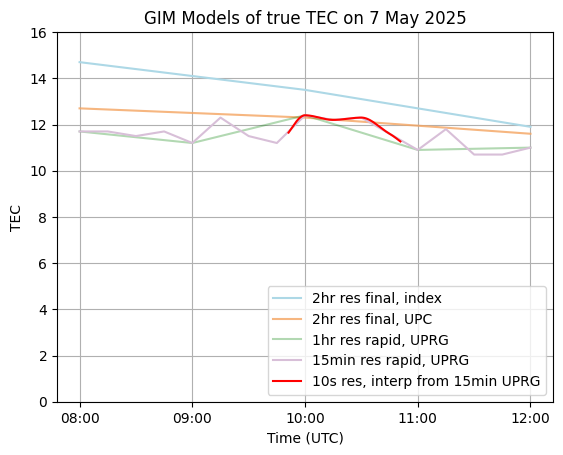

In [ ]:
#plot again with interpolated values


a = ovro_tec_2h.copy().drop(columns=['Lat','Lon']) # 2 hour final, index
b = ovro_tec_2h_r.copy().drop(columns=['Lat','Lon']) # 2 hour final, UPC
c = ovro_tec_1h.copy().drop(columns=['Lat','Lon']) # 1 hour rapid
d = ovro_tec_15m.copy().drop(columns=['Lat','Lon']) # 15 min rapid, potentially lower quality UPRG
e = gim_tec

fig, ax = plt.subplots()
ax.plot(a['DateTime'], a['TEC'], label = '2hr res final, index', alpha=1, c='lightblue')
ax.plot(b['DateTime'], b['TEC'], label = '2hr res final, UPC', alpha=0.8, c='sandybrown')
ax.plot(c['DateTime'], c['TEC'], label = '1hr res rapid, UPRG', alpha=0.3, c='green')
ax.plot(d['DateTime'], d['TEC'], label = '15min res rapid, UPRG', alpha=1, c='thistle')
ax.plot(e['DateTime'], e['TEC'], label = '10s res, interp from 15min UPRG', c='red')

ax.set_ylim(0,16)

ax.set(xlabel='Time (UTC)', ylabel='TEC',
       title='GIM Models of true TEC on 7 May 2025')
ax.grid()

ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) # For hours
plt.legend(loc="lower right")

plt.show()

In [ ]:
combined_csv_path = os.path.join(output_path, str(date), f"{date}_{freq}MHz_GIM_TEC.csv")

gim_tec.to_csv(combined_csv_path, index=False)

print(f"Exported GIM-TEC csv. {datetime.now(pytz.timezone("US/Pacific")).strftime("%b %d, %Y at %H:%M:%S")}")

Exported GIM-TEC csv. Jul 21, 2026 at 11:23:30
